In [29]:
import pandas as pd
from scipy.stats import bootstrap
import scipy

from matplotlib import pyplot as plt
from matplotlib.ticker import FormatStrFormatter
import numpy as np

import warnings
warnings.filterwarnings('ignore')


In [ ]:
ground_states = {"4": -0.7807764064044145}

In [31]:


def mean_confidence_interval(data, confidence):
    res = bootstrap(
        data=(data,),
        statistic=np.mean,            
        method="BCa",                 
        confidence_level = confidence,
        n_resamples=10000
    )

    ci_low, ci_high = res.confidence_interval.low, res.confidence_interval.high

    mean = data.mean()

    return mean, ci_low, ci_high


def compute_mean_and_confidence(df, runs, confidence):
    means = []
    lower_bounds = []
    upper_bounds = []

    for i, row in df.iterrows():
        mean, lower_bound, upper_bound = mean_confidence_interval(data = row[:runs], confidence = confidence)
        
        means.append(mean)
        lower_bounds.append(lower_bound)
        upper_bounds.append(upper_bound)

    return np.array(means), np.array(lower_bounds), np.array(upper_bounds)



## Rotosolve results

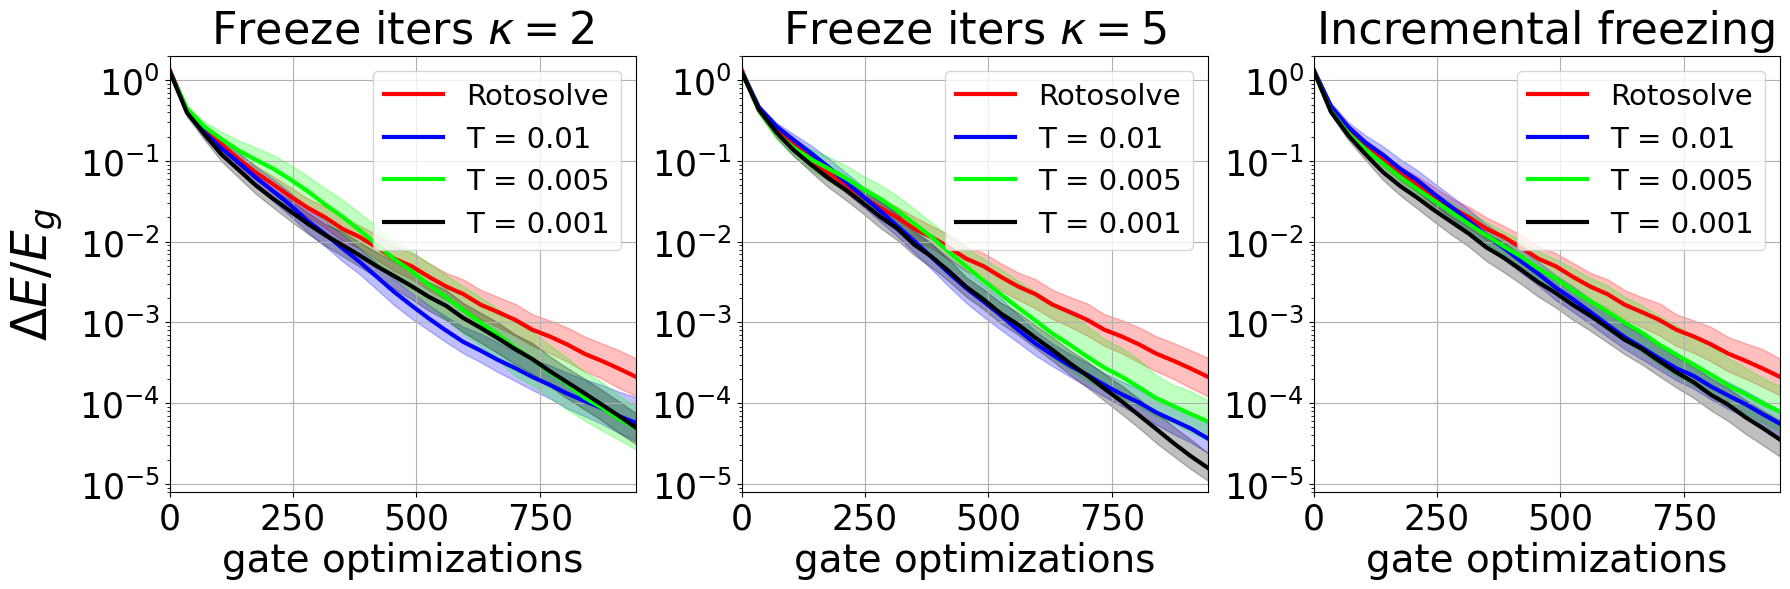

In [32]:
data_folder_rotosolve = f"../../data_folders/FermiHubbard_4Q_Rotosolve_data"

rows, cols = 1, 2
qubit = 2 * rows * cols
iters = 10
layers = 3*qubit
trials = 20

show_std = True
conf_level = 0.9

dvals = [0.01, 0.005, 0.001]

freeze_iters = [2, 5,  "inc"]

colors = ["blue", "lime", "black"]

fig, axes = plt.subplots(1, len(freeze_iters))

fig.set_figheight(6)
fig.set_figwidth(18)

if len(freeze_iters) == 1:
    axes = [axes]


# select every k-th row for faster plotting
every_n_row = 35

for fiter, ax in zip(freeze_iters, axes):
    df1 = pd.read_excel(f"{data_folder_rotosolve}/2DFermiHubbard_{rows}x{cols}_{qubit}Q_rotosolve_{iters}cycles_{layers}layers_{trials}trials.xlsx")
    df1 = np.abs((df1 - ground_states[f"{qubit}"]) / ground_states[f"{qubit}"])
    df1 = df1.iloc[::every_n_row, :]
    
    mean1, lb1, ub1 = compute_mean_and_confidence(df1, runs=trials, confidence=conf_level)
    xx1 = np.arange(0, every_n_row*len(mean1), every_n_row)
    ax.plot(xx1, mean1, lw=3, color="red", label="Rotosolve")

    if show_std:
        ax.fill_between(xx1, ub1, lb1, alpha = 0.25, color="red")


    for d, color in zip(dvals, colors):
        
        if fiter == "inc":
            df2 = pd.read_excel(f"{data_folder_rotosolve}/2DFermiHubbard_{rows}x{cols}_{qubit}Q_rotosolve_GateFreeze_d{d}_FreezeIterInc_{iters}cycles_{layers}layers_{trials}trials.xlsx")
            
        else:
            df2 = pd.read_excel(f"{data_folder_rotosolve}/2DFermiHubbard_{rows}x{cols}_{qubit}Q_rotosolve_GateFreeze_d{d}_FreezeIters{fiter}_{iters}cycles_{layers}layers_{trials}trials.xlsx")
        
        df2 = np.abs((df2 - ground_states[f"{qubit}"]) / ground_states[f"{qubit}"])
        df2 = df2.iloc[::every_n_row, :]
        mean2, lb2, ub2 = compute_mean_and_confidence(df2, runs=trials, confidence=conf_level)
        xx = np.arange(0, every_n_row*len(mean2), every_n_row)


        ax.plot(xx, mean2, lw=3, color=color, label=f"T = {d}")

        if show_std:
            ax.fill_between(xx, ub2, lb2, alpha = 0.25, color=color)

    if fiter == "inc":
        ax.set_title(f"Incremental freezing", fontsize=32, y=1.01)
    else:
        ax.set_title(f"Freeze iters $\kappa={fiter}$", fontsize=32, y=1.01)

    ax.set_xlabel("gate optimizations", fontsize=28)
    
    ax.tick_params(labelsize=25)

    ax.set_xlim(0, max(xx1))
    ax.set_yscale("log")
    ax.set_ylim(8e-6, 2e0)

    ax.grid()
    ax.legend(fontsize=21)


axes[0].set_ylabel(r"$\Delta E / E_g$", fontsize=35, labelpad = 10)
fig.tight_layout()



Rotosolve, Median=6.107712615663295e-05
T=0.01, Median=2.6370617151161636e-05
T=0.005, Median=1.3525568754724287e-05
T=0.001, Median=2.178693966013739e-05

Rotosolve, Median=6.107712615663295e-05
T=0.01, Median=1.633289314592372e-05
T=0.005, Median=1.8892417040281393e-05
T=0.001, Median=1.0129738788193078e-05

Rotosolve, Median=6.107712615663295e-05
T=0.01, Median=3.866247405951406e-05
T=0.005, Median=3.108584546115691e-05
T=0.001, Median=1.5944644452982077e-05


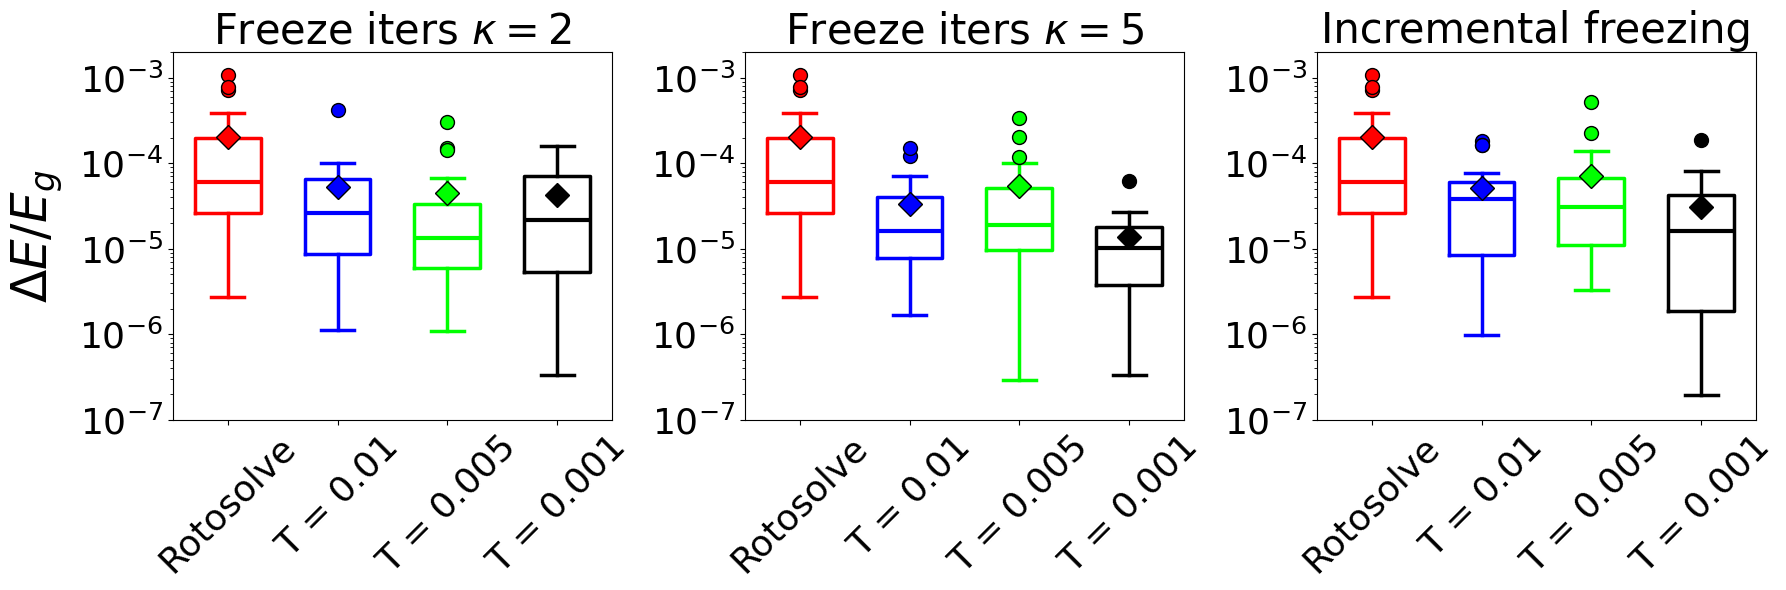

In [33]:
data_folder_rotosolve = f"../../data_folders/FermiHubbard_4Q_Rotosolve_data"

rows, cols = 1, 2
qubit = 2 * rows * cols
iters = 10
layers = 3*qubit
trials = 20

freeze_iters = [2,5, "inc"]


vals = [0.01, 0.005 ,0.001]

lw = 2.5

fig, axes = plt.subplots(1,len(freeze_iters))
axes = axes.flatten()

fig.set_figheight(6)
fig.set_figwidth(18)

colors = ["red", "blue", "lime", "black", "orange", "darkred"]

xtiks = ["Rotosolve", "T = 0.01", "T = 0.005", "T = 0.001"]

for ax, freeze_iter in zip(axes, freeze_iters):
    
    df1 = pd.read_excel(f"{data_folder_rotosolve}/2DFermiHubbard_{rows}x{cols}_{qubit}Q_rotosolve_{iters}cycles_{layers}layers_{trials}trials.xlsx")
    df1 = np.abs((df1 -ground_states[f"{qubit}"]) /ground_states[f"{qubit}"])

    len_roto = len(df1)

    if freeze_iter == "inc":
        df2 = pd.read_excel(f"{data_folder_rotosolve}/2DFermiHubbard_{rows}x{cols}_{qubit}Q_rotosolve_GateFreeze_d0.01_FreezeIterInc_{iters}cycles_{layers}layers_{trials}trials.xlsx")
        df3 = pd.read_excel(f"{data_folder_rotosolve}/2DFermiHubbard_{rows}x{cols}_{qubit}Q_rotosolve_GateFreeze_d0.005_FreezeIterInc_{iters}cycles_{layers}layers_{trials}trials.xlsx")
        df4 = pd.read_excel(f"{data_folder_rotosolve}/2DFermiHubbard_{rows}x{cols}_{qubit}Q_rotosolve_GateFreeze_d0.001_FreezeIterInc_{iters}cycles_{layers}layers_{trials}trials.xlsx")
        
    else:
        df2 = pd.read_excel(f"{data_folder_rotosolve}/2DFermiHubbard_{rows}x{cols}_{qubit}Q_rotosolve_GateFreeze_d0.01_FreezeIters{freeze_iter}_{iters}cycles_{layers}layers_{trials}trials.xlsx")
        df3 = pd.read_excel(f"{data_folder_rotosolve}/2DFermiHubbard_{rows}x{cols}_{qubit}Q_rotosolve_GateFreeze_d0.005_FreezeIters{freeze_iter}_{iters}cycles_{layers}layers_{trials}trials.xlsx")
        df4 = pd.read_excel(f"{data_folder_rotosolve}/2DFermiHubbard_{rows}x{cols}_{qubit}Q_rotosolve_GateFreeze_d0.001_FreezeIters{freeze_iter}_{iters}cycles_{layers}layers_{trials}trials.xlsx")
    
    df2 = np.abs((df2 -ground_states[f"{qubit}"]) /ground_states[f"{qubit}"])
    df3 = np.abs((df3 -ground_states[f"{qubit}"]) /ground_states[f"{qubit}"])
    df4 = np.abs((df4 -ground_states[f"{qubit}"]) /ground_states[f"{qubit}"])
    
    df2 = df2[:len_roto]
    df3 = df3[:len_roto]
    df4 = df4[:len_roto]

    row1 = df1.iloc[-1].to_numpy()
    row2 = df2.iloc[-1].to_numpy()
    row3 = df3.iloc[-1].to_numpy()
    row4 = df4.iloc[-1].to_numpy()

    median1 = np.median(row1) 
    median2 = np.median(row2)
    median3 = np.median(row3)
    median4 = np.median(row4)

    print(f"\nRotosolve, Median={np.median(row1)}")
    print(f"T=0.01, Median={np.median(row2)}")
    print(f"T=0.005, Median={np.median(row3)}")
    print(f"T=0.001, Median={np.median(row4)}")

    data = [row1, row2, row3, row4]

    for i, (dat, color) in enumerate(zip(data, colors), 0):

        meanpointprops = dict(marker='D', markeredgecolor='black',
                      markerfacecolor=color, markersize=12)

        ax.boxplot(dat, positions=[i], widths=0.6,
                patch_artist=False,
                boxprops=dict(color=color, linewidth=2.5),      # Box color and thickness
                capprops=dict(color=color, linewidth=2.5),                       # Cap color and thickness
                whiskerprops=dict(color=color, linewidth=2.5),                   # Whisker color and thickness
                medianprops=dict(color=color, linewidth=3),
                meanprops=meanpointprops,
                showmeans=True,
                flierprops = dict(markersize=10, markeredgecolor='black', markerfacecolor=color)
        )

    ax.set_xticklabels(xtiks, rotation=45)
    ax.tick_params(labelsize=26)
    ax.set_yscale("log")

    if freeze_iter == "inc":
        ax.set_title(f"Incremental freezing", fontsize=30)
    else:
        ax.set_title(f"Freeze iters $\kappa={freeze_iter}$", fontsize=30)
    
    ax.set_ylim(1e-7, 2e-3)

axes[0].set_ylabel(r"$\Delta E / E_g$", fontsize=35, labelpad = 10)
fig.tight_layout()

# Fraxis results

### Fraxis - Parameter distance metric

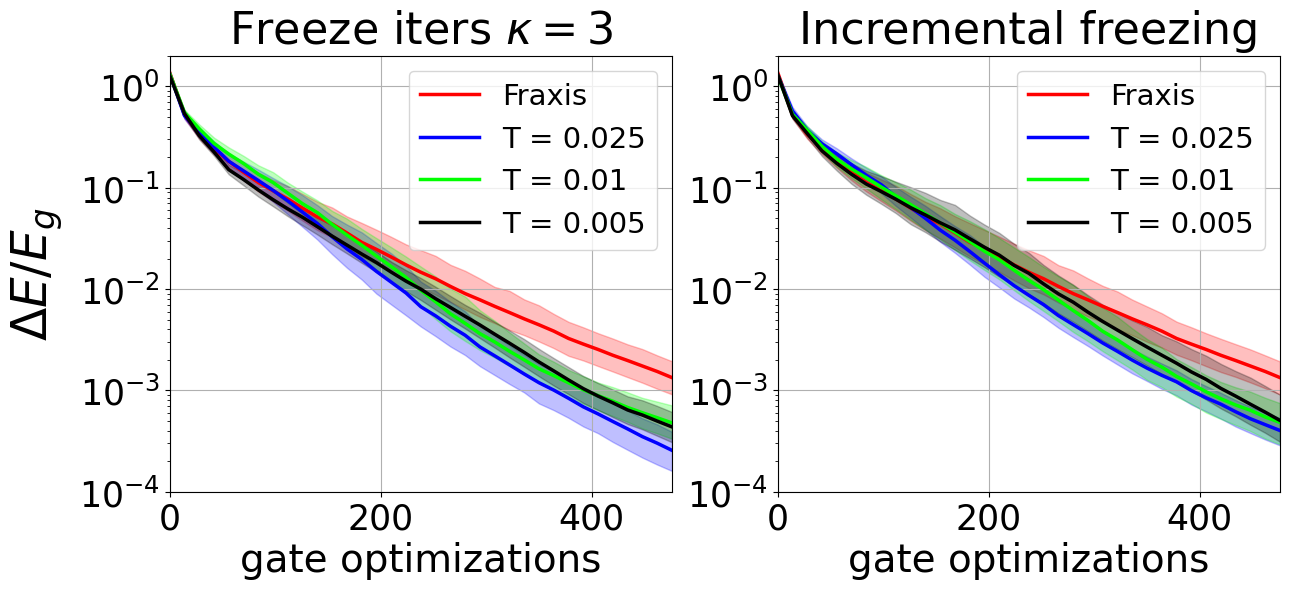

In [34]:
data_folder_fraxis = f"../../data_folders/FermiHubbard_4Q_Fraxis_data"

rows, cols = 1, 2
qubit = 2 * rows * cols
iters = 10
layers = 3*qubit
trials = 20

show_std = True
conf_level = 0.9

dvals = [0.025, 0.01, 0.005]

freeze_iters = [3,  "inc"]

colors = ["blue", "lime", "black"]

fig, axes = plt.subplots(1, len(freeze_iters))

fig.set_figheight(6)
fig.set_figwidth(13)

if len(freeze_iters) == 1:
    axes = [axes]

every_n_row = 14

for fiter, ax in zip(freeze_iters, axes):
    df1 = pd.read_excel(f"{data_folder_fraxis}/2DFermiHubbard_{rows}x{cols}_{qubit}Q_Fraxis_{iters}cycles_{layers}layers_{trials}trials.xlsx")
    df1 = np.abs((df1 - ground_states[f"{qubit}"]) / ground_states[f"{qubit}"])
    df1 = df1.iloc[::every_n_row, :]
    mean1, lb1, ub1 = compute_mean_and_confidence(df1, runs=trials, confidence=conf_level)
    xx1 = np.arange(0, every_n_row*len(mean1), every_n_row)
    ax.plot(xx1, mean1, lw=2.5, color="red", label="Fraxis")

    if show_std:
        ax.fill_between(xx1, ub1, lb1, alpha = 0.25, color="red")


    for d, color in zip(dvals, colors):
        
        if fiter == "inc":
            df2 = pd.read_excel(f"{data_folder_fraxis}/2DFermiHubbard_{rows}x{cols}_{qubit}Q_Fraxis_GCdist_d{d}_FreezeIterInc_{iters}cycles_{layers}layers_{trials}trials_A.xlsx")
            
        else:
            df2 = pd.read_excel(f"{data_folder_fraxis}/2DFermiHubbard_{rows}x{cols}_{qubit}Q_Fraxis_GCdist_d{d}_FreezeIter{fiter}_{iters}cycles_{layers}layers_{trials}trials_A.xlsx")
        
        df2 = np.abs((df2 - ground_states[f"{qubit}"]) / ground_states[f"{qubit}"])
        df2 = df2.iloc[::every_n_row, :]
        mean2, lb2, ub2 = compute_mean_and_confidence(df2, runs=trials, confidence=conf_level)
        xx = np.arange(0, every_n_row*len(mean2), every_n_row)


        ax.plot(xx, mean2, lw=2.5, color=color, label=f"T = {d}")

        if show_std:
            ax.fill_between(xx, ub2, lb2, alpha = 0.25, color=color)

    

    if fiter == "inc":
        ax.set_title(f"Incremental freezing", fontsize=32, y=1.01)
    else:
        ax.set_title(f"Freeze iters $\kappa={fiter}$", fontsize=32, y=1.01)

    ax.set_xlabel("gate optimizations", fontsize=28)
    ax.tick_params(labelsize=25)
    ax.set_xlim(0, max(xx1))
    ax.set_ylim(1e-4, 2e0)
    ax.set_yscale("log")
    ax.grid()
    ax.legend(fontsize=21)


axes[0].set_ylabel(r"$\Delta E / E_g$", fontsize=35, labelpad = 10)
fig.tight_layout()


Fraxis, Median=0.0007047057936091202
T=0.025, Median=8.2148639626144e-05
T=0.01, Median=0.000296730603977427
T=0.005, Median=0.0003763679435649847

Fraxis, Median=0.0007047057936091202
T=0.025, Median=0.00028627922762564063
T=0.01, Median=9.949976989184903e-05
T=0.005, Median=0.00025951412991963773


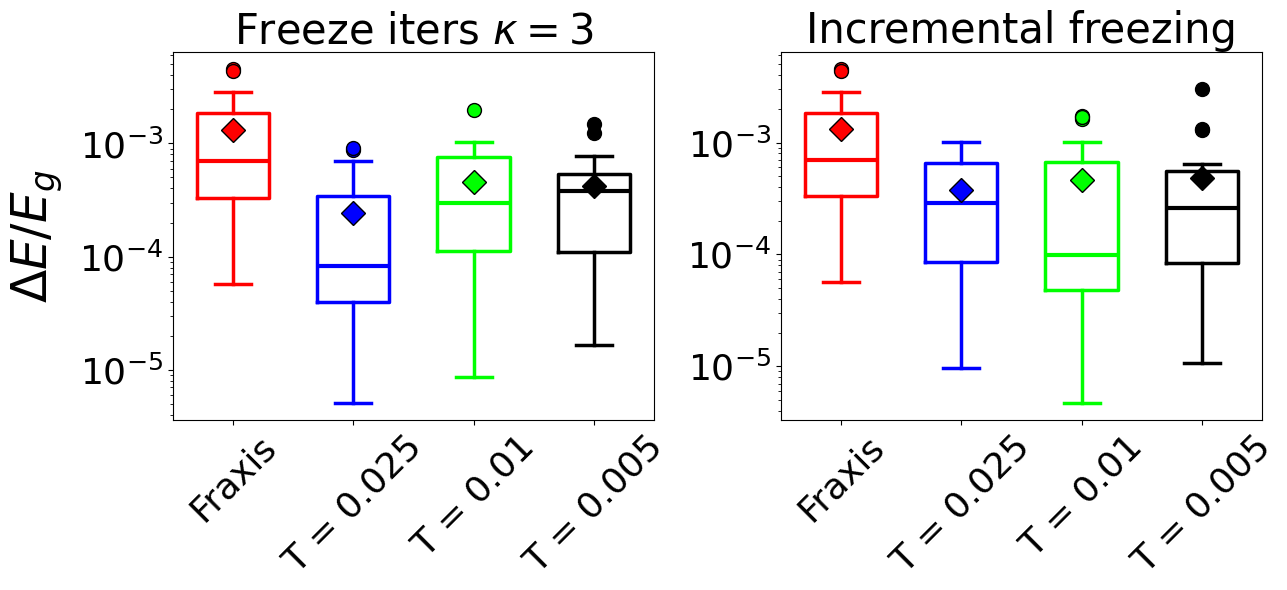

In [35]:
data_folder_fraxis = f"../../data_folders/FermiHubbard_4Q_Fraxis_data"

rows, cols = 1, 2
qubit = 2 * rows * cols
iters = 10
layers = 3*qubit
trials = 20

freeze_iters = [3, "inc"]


vals = [0.025, 0.01 ,0.005]

lw = 2.5

fig, axes = plt.subplots(1,len(freeze_iters))
axes = axes.flatten()

fig.set_figheight(6)
fig.set_figwidth(13)

colors = ["red", "blue", "lime", "black", "orange", "darkred"]

xtiks = ["Fraxis", "T = 0.025", "T = 0.01", "T = 0.005"]

for ax, freeze_iter in zip(axes, freeze_iters):
    
    df1 = pd.read_excel(f"{data_folder_fraxis}/2DFermiHubbard_{rows}x{cols}_{qubit}Q_Fraxis_{iters}cycles_{layers}layers_{trials}trials.xlsx")
    df1 = np.abs((df1 - ground_states[f"{qubit}"]) / ground_states[f"{qubit}"])

    if freeze_iter == "inc":
        df2 = pd.read_excel(f"{data_folder_fraxis}/2DFermiHubbard_{rows}x{cols}_{qubit}Q_Fraxis_GCdist_d0.025_FreezeIterInc_{iters}cycles_{layers}layers_{trials}trials_A.xlsx")
        df3 = pd.read_excel(f"{data_folder_fraxis}/2DFermiHubbard_{rows}x{cols}_{qubit}Q_Fraxis_GCdist_d0.01_FreezeIterInc_{iters}cycles_{layers}layers_{trials}trials_A.xlsx")
        df4 = pd.read_excel(f"{data_folder_fraxis}/2DFermiHubbard_{rows}x{cols}_{qubit}Q_Fraxis_GCdist_d0.005_FreezeIterInc_{iters}cycles_{layers}layers_{trials}trials_A.xlsx")
        
    else:
        df2 = pd.read_excel(f"{data_folder_fraxis}/2DFermiHubbard_{rows}x{cols}_{qubit}Q_Fraxis_GCdist_d0.025_FreezeIter{freeze_iter}_{iters}cycles_{layers}layers_{trials}trials_A.xlsx")
        df3 = pd.read_excel(f"{data_folder_fraxis}/2DFermiHubbard_{rows}x{cols}_{qubit}Q_Fraxis_GCdist_d0.01_FreezeIter{freeze_iter}_{iters}cycles_{layers}layers_{trials}trials_A.xlsx")
        df4 = pd.read_excel(f"{data_folder_fraxis}/2DFermiHubbard_{rows}x{cols}_{qubit}Q_Fraxis_GCdist_d0.005_FreezeIter{freeze_iter}_{iters}cycles_{layers}layers_{trials}trials_A.xlsx")
    
    df2 = np.abs((df2 - ground_states[f"{qubit}"]) / ground_states[f"{qubit}"])
    df3 = np.abs((df3 - ground_states[f"{qubit}"]) / ground_states[f"{qubit}"])
    df4 = np.abs((df4 - ground_states[f"{qubit}"]) / ground_states[f"{qubit}"])
    
    row1 = df1.iloc[-1].to_numpy()
    row2 = df2.iloc[-1].to_numpy()
    row3 = df3.iloc[-1].to_numpy()
    row4 = df4.iloc[-1].to_numpy()

    median1 = np.median(row1) 
    median2 = np.median(row2)
    median3 = np.median(row3)
    median4 = np.median(row4)

    print(f"\nFraxis, Median={np.median(row1)}")
    print(f"T=0.025, Median={np.median(row2)}")
    print(f"T=0.01, Median={np.median(row3)}")
    print(f"T=0.005, Median={np.median(row4)}")

    data = [row1, row2, row3, row4]

    for i, (dat, color) in enumerate(zip(data, colors), 0):

        meanpointprops = dict(marker='D', markeredgecolor='black',
                      markerfacecolor=color, markersize=12)

        ax.boxplot(dat, positions=[i], widths=0.6,
                patch_artist=False,
                boxprops=dict(color=color, linewidth=2.5),      # Box color and thickness
                capprops=dict(color=color, linewidth=2.5),                       # Cap color and thickness
                whiskerprops=dict(color=color, linewidth=2.5),                   # Whisker color and thickness
                medianprops=dict(color=color, linewidth=3),
                meanprops=meanpointprops,
                showmeans=True,
                flierprops = dict(markersize=10, markeredgecolor='black', markerfacecolor=color)
        )

    ax.set_xticklabels(xtiks, rotation=45)
    ax.tick_params(labelsize=26)
    ax.set_yscale("log")

    if freeze_iter == "inc":
        ax.set_title(f"Incremental freezing", fontsize=30)
    else:
        ax.set_title(f"Freeze iters $\kappa={freeze_iter}$", fontsize=30)
    

axes[0].set_ylabel(r"$\Delta E / E_g$", fontsize=35, labelpad = 10)
fig.tight_layout()

### Fraxis - Matrix norm metric

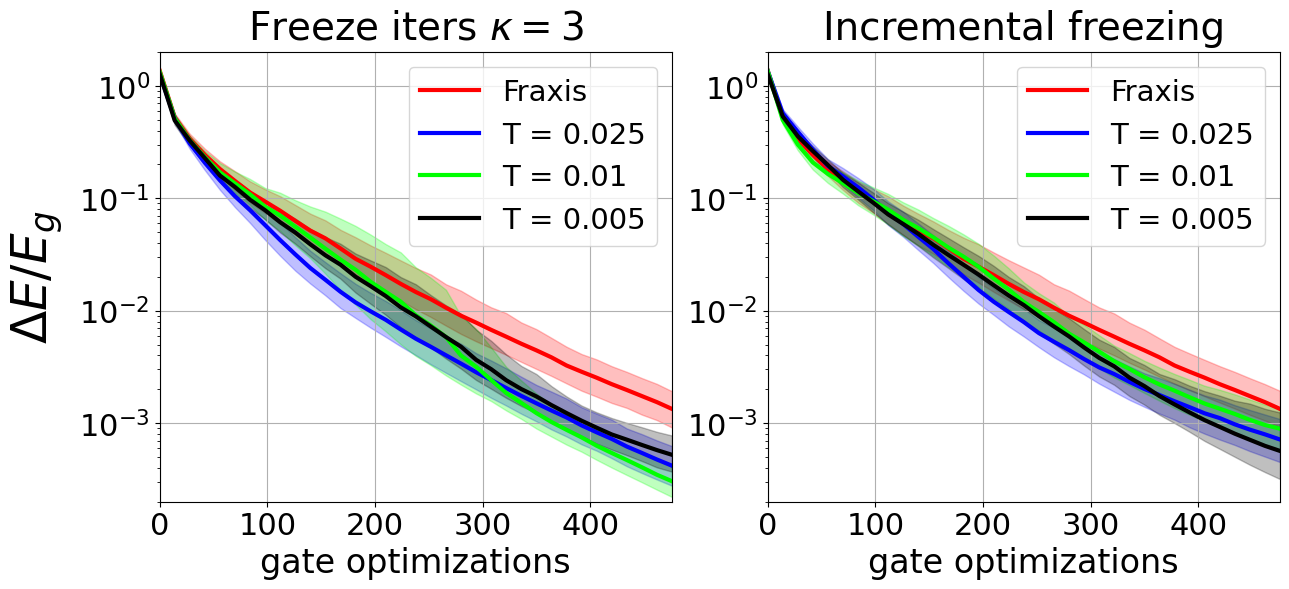

In [36]:
data_folder_fraxis = f"../../data_folders/FermiHubbard_4Q_Fraxis_matrix_norm_data"

rows, cols = 1, 2
qubit = 2 * rows * cols
iters = 10
layers = 3*qubit
trials = 20

show_std = True
conf_level = 0.9

dvals = [0.025, 0.01, 0.005]

freeze_iters = [3,  "inc"]

colors = ["blue", "lime", "black"]

fig, axes = plt.subplots(1, len(freeze_iters))

fig.set_figheight(6)
fig.set_figwidth(13)

if len(freeze_iters) == 1:
    axes = [axes]

every_n_row = 14

for fiter, ax in zip(freeze_iters, axes):
    df1 = pd.read_excel(f"{data_folder_fraxis}/2DFermiHubbard_{rows}x{cols}_{qubit}Q_Fraxis_{iters}cycles_{layers}layers_{trials}trials.xlsx")
    df1 = np.abs((df1 - ground_states[f"{qubit}"]) / ground_states[f"{qubit}"])
    df1 = df1.iloc[::every_n_row, :]
    mean1, lb1, ub1 = compute_mean_and_confidence(df1, runs=trials, confidence=conf_level)
    xx1 = np.arange(0, every_n_row*len(mean1), every_n_row)
    ax.plot(xx1, mean1, lw=3, color="red", label="Fraxis")

    if show_std:
        ax.fill_between(xx1, ub1, lb1, alpha = 0.25, color="red")


    for d, color in zip(dvals, colors):
        
        if fiter == "inc":
            df2 = pd.read_excel(f"{data_folder_fraxis}/MatrixNorm_2DFermiHubbard_{rows}x{cols}_{qubit}Q_Fraxis_GateFreeze_d{d}_FreezeIterInc_{iters}cycles_{layers}layers_{trials}trials_A.xlsx")
            
        else:
            df2 = pd.read_excel(f"{data_folder_fraxis}/MatrixNorm_2DFermiHubbard_{rows}x{cols}_{qubit}Q_Fraxis_GateFreeze_d{d}_FreezeIter{fiter}_{iters}cycles_{layers}layers_{trials}trials_A.xlsx")
        
        df2 = np.abs((df2 - ground_states[f"{qubit}"]) / ground_states[f"{qubit}"])
        df2 = df2.iloc[::every_n_row, :]
        mean2, lb2, ub2 = compute_mean_and_confidence(df2, runs=trials, confidence=conf_level)
        xx = np.arange(0, every_n_row*len(mean2), every_n_row)

        ax.plot(xx, mean2, lw=3, color=color, label=f"T = {d}")

        if show_std:
            ax.fill_between(xx, ub2, lb2, alpha = 0.25, color=color)

    
    if fiter == "inc":
        ax.set_title(f"Incremental freezing", fontsize=28, y=1.01)
    else:
        ax.set_title(f"Freeze iters $\kappa={fiter}$", fontsize=28, y=1.01)

    ax.set_xlabel("gate optimizations", fontsize=24)
    
    ax.tick_params(labelsize=22)

    ax.set_xlim(0, max(xx1))
    ax.set_yscale("log")
    ax.set_ylim(2e-4, 2e0)
    ax.grid()
    ax.legend(fontsize=21)


axes[0].set_ylabel(r"$\Delta E / E_g$", fontsize=35, labelpad = 10)
fig.tight_layout()


Fraxis, Median=0.0007047057936091202
T=0.025, Median=0.00022330491600101458
T=0.01, Median=0.00025214481100859084
T=0.005, Median=0.0002867770841547526

Fraxis, Median=0.0007047057936091202
T=0.025, Median=0.00035253770647274265
T=0.01, Median=0.0005067040458611911
T=0.005, Median=0.0002878186389247532


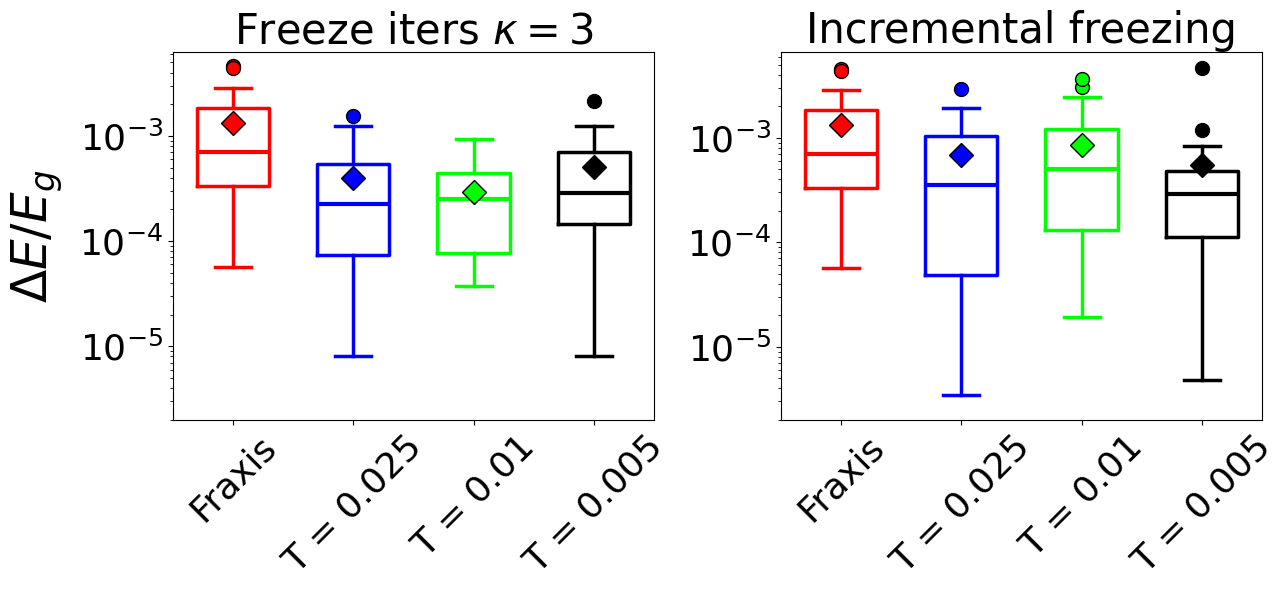

In [37]:
data_folder_fraxis = f"../../data_folders/FermiHubbard_4Q_Fraxis_matrix_norm_data"

rows, cols = 1, 2
qubit = 2 * rows * cols
iters = 10
layers = 3*qubit
trials = 20

freeze_iters = [3, "inc"]


vals = [0.01, 0.005 ,0.001]

lw = 2.5

fig, axes = plt.subplots(1,len(freeze_iters))
axes = axes.flatten()

fig.set_figheight(6)
fig.set_figwidth(13)

colors = ["red", "blue", "lime", "black", "orange", "darkred"]

xtiks = ["Fraxis", "T = 0.025", "T = 0.01", "T = 0.005"]

for ax, freeze_iter in zip(axes, freeze_iters):
    
    df1 = pd.read_excel(f"{data_folder_fraxis}/2DFermiHubbard_{rows}x{cols}_{qubit}Q_Fraxis_{iters}cycles_{layers}layers_{trials}trials.xlsx")
    df1 = np.abs((df1 - ground_states[f"{qubit}"]) / ground_states[f"{qubit}"])

    if freeze_iter == "inc":
        df2 = pd.read_excel(f"{data_folder_fraxis}/MatrixNorm_2DFermiHubbard_{rows}x{cols}_{qubit}Q_Fraxis_GateFreeze_d0.025_FreezeIterInc_{iters}cycles_{layers}layers_{trials}trials_A.xlsx")
        df3 = pd.read_excel(f"{data_folder_fraxis}/MatrixNorm_2DFermiHubbard_{rows}x{cols}_{qubit}Q_Fraxis_GateFreeze_d0.01_FreezeIterInc_{iters}cycles_{layers}layers_{trials}trials_A.xlsx")
        df4 = pd.read_excel(f"{data_folder_fraxis}/MatrixNorm_2DFermiHubbard_{rows}x{cols}_{qubit}Q_Fraxis_GateFreeze_d0.005_FreezeIterInc_{iters}cycles_{layers}layers_{trials}trials_A.xlsx")
        
    else:
        df2 = pd.read_excel(f"{data_folder_fraxis}/MatrixNorm_2DFermiHubbard_{rows}x{cols}_{qubit}Q_Fraxis_GateFreeze_d0.025_FreezeIter{freeze_iter}_{iters}cycles_{layers}layers_{trials}trials_A.xlsx")
        df3 = pd.read_excel(f"{data_folder_fraxis}/MatrixNorm_2DFermiHubbard_{rows}x{cols}_{qubit}Q_Fraxis_GateFreeze_d0.01_FreezeIter{freeze_iter}_{iters}cycles_{layers}layers_{trials}trials_A.xlsx")
        df4 = pd.read_excel(f"{data_folder_fraxis}/MatrixNorm_2DFermiHubbard_{rows}x{cols}_{qubit}Q_Fraxis_GateFreeze_d0.005_FreezeIter{freeze_iter}_{iters}cycles_{layers}layers_{trials}trials_A.xlsx")
    
    df2 = np.abs((df2 - ground_states[f"{qubit}"]) / ground_states[f"{qubit}"])
    df3 = np.abs((df3 - ground_states[f"{qubit}"]) / ground_states[f"{qubit}"])
    df4 = np.abs((df4 - ground_states[f"{qubit}"]) / ground_states[f"{qubit}"])
    
    row1 = df1.iloc[-1].to_numpy()
    row2 = df2.iloc[-1].to_numpy()
    row3 = df3.iloc[-1].to_numpy()
    row4 = df4.iloc[-1].to_numpy()

    median1 = np.median(row1) 
    median2 = np.median(row2)
    median3 = np.median(row3)
    median4 = np.median(row4)

    print(f"\nFraxis, Median={np.median(row1)}")
    print(f"T=0.025, Median={np.median(row2)}")
    print(f"T=0.01, Median={np.median(row3)}")
    print(f"T=0.005, Median={np.median(row4)}")
    
    data = [row1, row2, row3, row4]

    for i, (dat, color) in enumerate(zip(data, colors), 0):

        meanpointprops = dict(marker='D', markeredgecolor='black',
                      markerfacecolor=color, markersize=12)

        ax.boxplot(dat, positions=[i], widths=0.6,
                patch_artist=False,
                boxprops=dict(color=color, linewidth=2.5),      # Box color and thickness
                capprops=dict(color=color, linewidth=2.5),                       # Cap color and thickness
                whiskerprops=dict(color=color, linewidth=2.5),                   # Whisker color and thickness
                medianprops=dict(color=color, linewidth=3),
                meanprops=meanpointprops,
                showmeans=True,
                flierprops = dict(markersize=10, markeredgecolor='black', markerfacecolor=color)
        )

    ax.set_xticklabels(xtiks, rotation=45)
    ax.tick_params(labelsize=26)
    ax.set_yscale("log")

    if freeze_iter == "inc":
        ax.set_title(f"Incremental freezing", fontsize=30)
    else:
        ax.set_title(f"Freeze iters $\kappa={freeze_iter}$", fontsize=30)
    
    ax.set_ylim(2e-6, -6e-3)

axes[0].set_ylabel(r"$\Delta E / E_g$", fontsize=35, labelpad = 10)

fig.tight_layout()


# FQS Results

### FQS - parameter distance metric

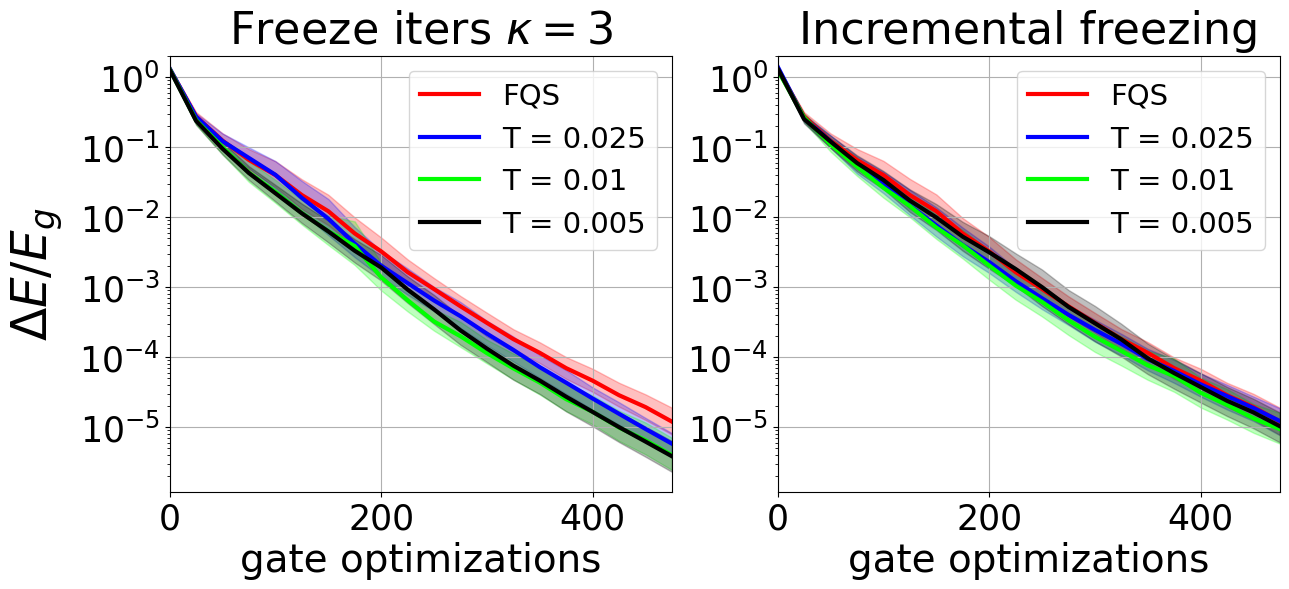

In [41]:
data_folder_fqs = f"../../data_folders/FermiHubbard_4Q_FQS_data"

rows, cols = 1, 2
qubit = 2 * rows * cols
iters = 10
layers = 3*qubit
trials = 20

show_std = True
conf_level = 0.9

dvals = [0.025, 0.01, 0.005]

freeze_iters = [3,  "inc"]

colors = ["blue", "lime", "black"]

fig, axes = plt.subplots(1, len(freeze_iters))

fig.set_figheight(6)
fig.set_figwidth(13)

if len(freeze_iters) == 1:
    axes = [axes]

every_n_row = 25

for fiter, ax in zip(freeze_iters, axes):
    df1 = pd.read_excel(f"{data_folder_fqs}/2DFermiHubbard_{rows}x{cols}_{qubit}Q_FQS_{iters}cycles_{layers}layers_{trials}trials_A.xlsx")
    df1 = np.abs((df1 - ground_states[f"{qubit}"]) / ground_states[f"{qubit}"])
    df1 = df1.iloc[::every_n_row, :]
    mean1, lb1, ub1 = compute_mean_and_confidence(df1, runs=trials, confidence=conf_level)
    xx1 = np.arange(0, every_n_row*len(mean1), every_n_row)
    ax.plot(xx1, mean1, lw=3, color="red", label="FQS")

    if show_std:
        ax.fill_between(xx1, ub1, lb1, alpha = 0.25, color="red")


    for d, color in zip(dvals, colors):
        
        if fiter == "inc":
            df2 = pd.read_excel(f"{data_folder_fqs}/2DFermiHubbard_{rows}x{cols}_{qubit}Q_FQS_GateFreeze_GCdist_d{d}_FreezeIterInc_{iters}cycles_{layers}layers_{trials}trials_A.xlsx")
            
        else:
            df2 = pd.read_excel(f"{data_folder_fqs}/2DFermiHubbard_{rows}x{cols}_{qubit}Q_FQS_GateFreeze_GCdist_d{d}_FreezeIter{fiter}_{iters}cycles_{layers}layers_{trials}trials_A.xlsx")
        
        df2 = np.abs((df2 - ground_states[f"{qubit}"]) / ground_states[f"{qubit}"])
        df2 = df2.iloc[::every_n_row, :]
        mean2, lb2, ub2 = compute_mean_and_confidence(df2, runs=trials, confidence=conf_level)
        xx = np.arange(0, every_n_row*len(mean2), every_n_row)

        ax.plot(xx, mean2, lw=3, color=color, label=f"T = {d}")

        if show_std:
            ax.fill_between(xx, ub2, lb2, alpha = 0.25, color=color)


    if fiter == "inc":
        ax.set_title(f"Incremental freezing", fontsize=32, y=1.01)
    else:
        ax.set_title(f"Freeze iters $\kappa={fiter}$", fontsize=32, y=1.01)

    ax.set_xlabel("gate optimizations", fontsize=28)
    ax.tick_params(labelsize=25)
    ax.set_xlim(0, max(xx1))
    ax.set_yscale("log")
    ax.set_ylim(1.2e-6, 2e0)
    ax.grid()
    ax.legend(fontsize=21)


axes[0].set_ylabel(r"$\Delta E / E_g$", fontsize=35, labelpad = 10)
fig.tight_layout()


FQS, Median=7.452617601807508e-06
T=0.01, Median=3.3127448797220375e-06
T=0.005, Median=1.3287308515159387e-06
T=0.001, Median=1.2807542322371333e-06

FQS, Median=7.452617601807508e-06
T=0.01, Median=4.425384381754545e-06
T=0.005, Median=2.6399507990628592e-06
T=0.001, Median=2.326607546410448e-06


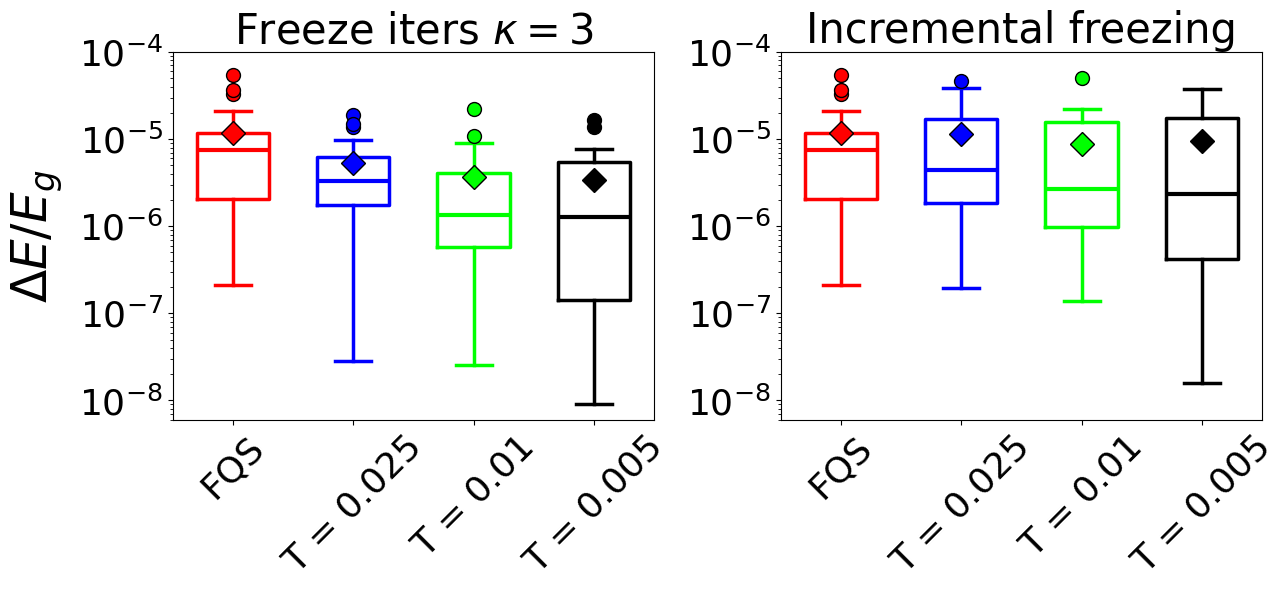

In [42]:
data_folder_fqs = f"../../data_folders/FermiHubbard_4Q_FQS_data"

rows, cols = 1, 2
qubit = 2 * rows * cols
iters = 10
layers = 3*qubit
trials = 20

freeze_iters = [3, "inc"]


vals = [0.01, 0.005 ,0.001]

lw = 2.5

fig, axes = plt.subplots(1,len(freeze_iters))
axes = axes.flatten()

fig.set_figheight(6)
fig.set_figwidth(13)

colors = ["red", "blue", "lime", "black", "orange", "darkred"]

xtiks = ["FQS", "T = 0.025", "T = 0.01", "T = 0.005"]

for ax, freeze_iter in zip(axes, freeze_iters):
    
    df1 = pd.read_excel(f"{data_folder_fqs}/2DFermiHubbard_{rows}x{cols}_{qubit}Q_FQS_{iters}cycles_{layers}layers_{trials}trials_A.xlsx")
    df1 = np.abs((df1 - ground_states[f"{qubit}"]) / ground_states[f"{qubit}"])

    if freeze_iter == "inc":
        df2 = pd.read_excel(f"{data_folder_fqs}/2DFermiHubbard_{rows}x{cols}_{qubit}Q_FQS_GateFreeze_GCdist_d0.025_FreezeIterInc_{iters}cycles_{layers}layers_{trials}trials_A.xlsx")
        df3 = pd.read_excel(f"{data_folder_fqs}/2DFermiHubbard_{rows}x{cols}_{qubit}Q_FQS_GateFreeze_GCdist_d0.01_FreezeIterInc_{iters}cycles_{layers}layers_{trials}trials_A.xlsx")
        df4 = pd.read_excel(f"{data_folder_fqs}/2DFermiHubbard_{rows}x{cols}_{qubit}Q_FQS_GateFreeze_GCdist_d0.005_FreezeIterInc_{iters}cycles_{layers}layers_{trials}trials_A.xlsx")
        
    else:
        df2 = pd.read_excel(f"{data_folder_fqs}/2DFermiHubbard_{rows}x{cols}_{qubit}Q_FQS_GateFreeze_GCdist_d0.025_FreezeIter{freeze_iter}_{iters}cycles_{layers}layers_{trials}trials_A.xlsx")
        df3 = pd.read_excel(f"{data_folder_fqs}/2DFermiHubbard_{rows}x{cols}_{qubit}Q_FQS_GateFreeze_GCdist_d0.01_FreezeIter{freeze_iter}_{iters}cycles_{layers}layers_{trials}trials_A.xlsx")
        df4 = pd.read_excel(f"{data_folder_fqs}/2DFermiHubbard_{rows}x{cols}_{qubit}Q_FQS_GateFreeze_GCdist_d0.005_FreezeIter{freeze_iter}_{iters}cycles_{layers}layers_{trials}trials_A.xlsx")
    
    df2 = np.abs((df2 - ground_states[f"{qubit}"]) / ground_states[f"{qubit}"])
    df3 = np.abs((df3 - ground_states[f"{qubit}"]) / ground_states[f"{qubit}"])
    df4 = np.abs((df4 - ground_states[f"{qubit}"]) / ground_states[f"{qubit}"])
    
    row1 = df1.iloc[-1].to_numpy()
    row2 = df2.iloc[-1].to_numpy()
    row3 = df3.iloc[-1].to_numpy()
    row4 = df4.iloc[-1].to_numpy()

    data = [row1, row2, row3, row4]

    median1 = np.median(row1) 
    median2 = np.median(row2)
    median3 = np.median(row3)
    median4 = np.median(row4)

    print(f"\nFQS, Median={np.median(row1)}")
    print(f"T=0.01, Median={np.median(row2)}")
    print(f"T=0.005, Median={np.median(row3)}")
    print(f"T=0.001, Median={np.median(row4)}")


    for i, (dat, color) in enumerate(zip(data, colors), 0):

        meanpointprops = dict(marker='D', markeredgecolor='black',
                      markerfacecolor=color, markersize=12)

        ax.boxplot(dat, positions=[i], widths=0.6,
                patch_artist=False,
                boxprops=dict(color=color, linewidth=2.5),      # Box color and thickness
                capprops=dict(color=color, linewidth=2.5),                       # Cap color and thickness
                whiskerprops=dict(color=color, linewidth=2.5),                   # Whisker color and thickness
                medianprops=dict(color=color, linewidth=3),
                meanprops=meanpointprops,
                showmeans=True,
                flierprops = dict(markersize=10, markeredgecolor='black', markerfacecolor=color)
        )

    ax.set_xticklabels(xtiks, rotation=45)
    ax.tick_params(labelsize=26)
    ax.set_yscale("log")

    if freeze_iter == "inc":
        ax.set_title(f"Incremental freezing", fontsize=30)
    else:
        ax.set_title(f"Freeze iters $\kappa={freeze_iter}$", fontsize=30)
    
    ax.set_ylim(6e-9, 1e-4)

axes[0].set_ylabel(r"$\Delta E / E_g$", fontsize=35, labelpad = 10)

fig.tight_layout()

### FQS - Matrix norm metric

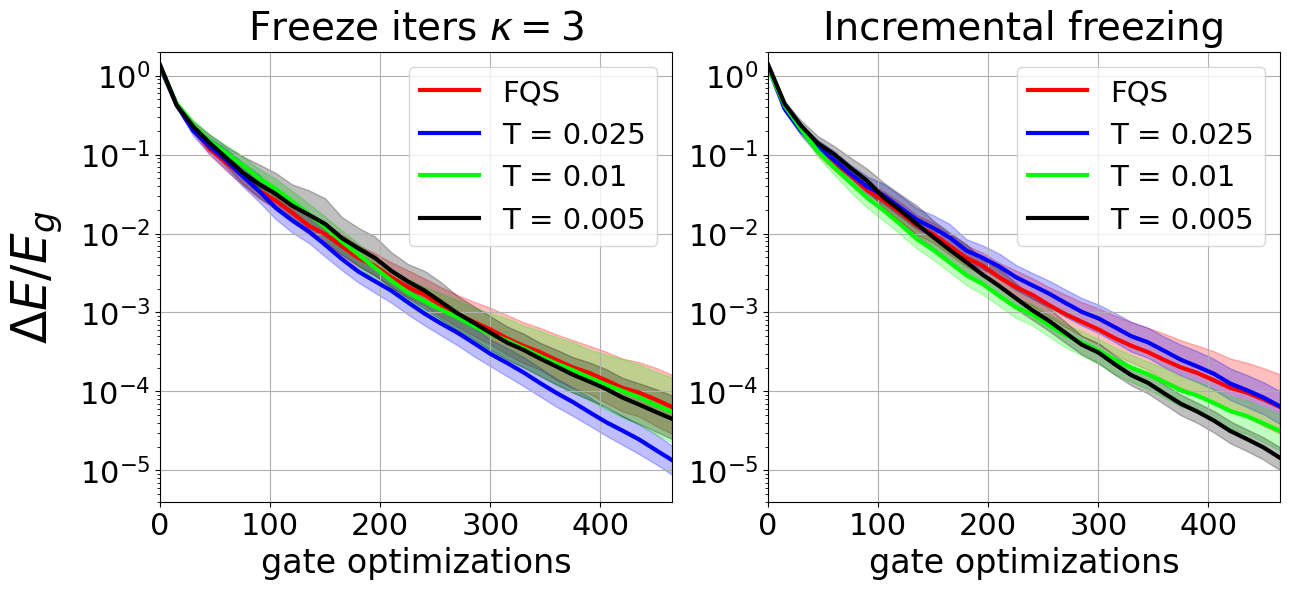

In [44]:
data_folder_fqs = f"../../data_folders/FermiHubbard_4Q_FQS_matrix_norm_data"

rows, cols = 1, 2
qubit = 2 * rows * cols
iters = 10
layers = 3*qubit
trials = 20

show_std = True
conf_level = 0.9

dvals = [0.025, 0.01, 0.005]

freeze_iters = [3,  "inc"]

colors = ["blue", "lime", "black"]

fig, axes = plt.subplots(1, len(freeze_iters))

fig.set_figheight(6)
fig.set_figwidth(13)

if len(freeze_iters) == 1:
    axes = [axes]

every_n_row = 15

for fiter, ax in zip(freeze_iters, axes):
    df1 = pd.read_excel(f"{data_folder_fqs}/2DFermiHubbard_{rows}x{cols}_{qubit}Q_FQS_{iters}cycles_{layers}layers_{trials}trials_A.xlsx")
    df1 = np.abs((df1 - ground_states[f"{qubit}"]) / ground_states[f"{qubit}"])
    df1 = df1.iloc[::every_n_row, :]
    mean1, lb1, ub1 = compute_mean_and_confidence(df1, runs=trials, confidence=conf_level)
    xx1 = np.arange(0, every_n_row*len(mean1), every_n_row)
    ax.plot(xx1, mean1, lw=3, color="red", label="FQS")

    if show_std:
        ax.fill_between(xx1, ub1, lb1, alpha = 0.25, color="red")


    for d, color in zip(dvals, colors):
        
        if fiter == "inc":
            df2 = pd.read_excel(f"{data_folder_fqs}/MatrixNorm_2DFermiHubbard_{rows}x{cols}_{qubit}Q_FQS_GateFreeze_d{d}_FreezeIterInc_{iters}cycles_{layers}layers_{trials}trials_A.xlsx")
            
        else:
            df2 = pd.read_excel(f"{data_folder_fqs}/MatrixNorm_2DFermiHubbard_{rows}x{cols}_{qubit}Q_FQS_GateFreeze_d{d}_FreezeIter{fiter}_{iters}cycles_{layers}layers_{trials}trials_A.xlsx")
        
        df2 = np.abs((df2 - ground_states[f"{qubit}"]) / ground_states[f"{qubit}"])
        df2 = df2.iloc[::every_n_row, :]
        mean2, lb2, ub2 = compute_mean_and_confidence(df2, runs=trials, confidence=conf_level)
        xx = np.arange(0, every_n_row*len(mean2), every_n_row)

        ax.plot(xx, mean2, lw=3, color=color, label=f"T = {d}")

        if show_std:
            ax.fill_between(xx, ub2, lb2, alpha = 0.25, color=color)

    
    if fiter == "inc":
        ax.set_title(f"Incremental freezing", fontsize=28, y=1.01)
    else:
        ax.set_title(f"Freeze iters $\kappa={fiter}$", fontsize=28, y=1.01)

    ax.set_xlabel("gate optimizations", fontsize=24)
    
    ax.tick_params(labelsize=22)

    ax.set_xlim(0, max(xx1))
    ax.set_yscale("log")
    ax.set_ylim(4e-6, 2e0)

    ax.grid()
    ax.legend(fontsize=21)


axes[0].set_ylabel(r"$\Delta E / E_g$", fontsize=35, labelpad = 10)
fig.tight_layout()




FQS, Median=1.5442355148781842e-05
T=0.01, Median=6.1531015334909614e-06
T=0.005, Median=1.1627210885721548e-05
T=0.001, Median=7.305994953372369e-06

FQS, Median=1.5442355148781842e-05
T=0.01, Median=1.3514839233207464e-05
T=0.005, Median=5.6512182599879645e-06
T=0.001, Median=1.0034547000009633e-05


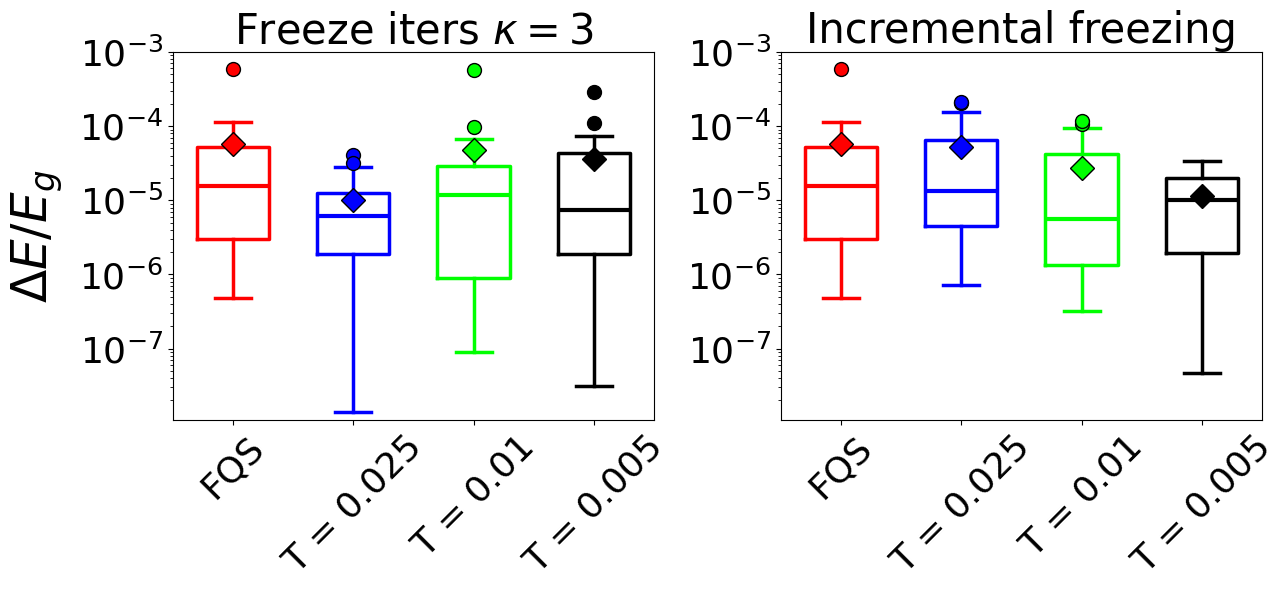

In [45]:
data_folder_fqs = f"../../data_folders/FermiHubbard_4Q_FQS_matrix_norm_data"

rows, cols = 1, 2
qubit = 2 * rows * cols
iters = 10
layers = 3*qubit
trials = 20

freeze_iters = [3, "inc"]


vals = [0.025, 0.01 ,0.005]

lw = 2.5

fig, axes = plt.subplots(1,len(freeze_iters))
axes = axes.flatten()

fig.set_figheight(6)
fig.set_figwidth(13)

colors = ["red", "blue", "lime", "black", "orange", "darkred"]

xtiks = ["FQS", "T = 0.025", "T = 0.01", "T = 0.005"]

for ax, freeze_iter in zip(axes, freeze_iters):
    
    df1 = pd.read_excel(f"{data_folder_fqs}/2DFermiHubbard_{rows}x{cols}_{qubit}Q_FQS_{iters}cycles_{layers}layers_{trials}trials_A.xlsx")
    df1 = np.abs((df1 - ground_states[f"{qubit}"]) / ground_states[f"{qubit}"])

    if freeze_iter == "inc":
        df2 = pd.read_excel(f"{data_folder_fqs}/MatrixNorm_2DFermiHubbard_{rows}x{cols}_{qubit}Q_FQS_GateFreeze_d0.025_FreezeIterInc_{iters}cycles_{layers}layers_{trials}trials_A.xlsx")
        df3 = pd.read_excel(f"{data_folder_fqs}/MatrixNorm_2DFermiHubbard_{rows}x{cols}_{qubit}Q_FQS_GateFreeze_d0.01_FreezeIterInc_{iters}cycles_{layers}layers_{trials}trials_A.xlsx")
        df4 = pd.read_excel(f"{data_folder_fqs}/MatrixNorm_2DFermiHubbard_{rows}x{cols}_{qubit}Q_FQS_GateFreeze_d0.005_FreezeIterInc_{iters}cycles_{layers}layers_{trials}trials_A.xlsx")
        
    else:
        df2 = pd.read_excel(f"{data_folder_fqs}/MatrixNorm_2DFermiHubbard_{rows}x{cols}_{qubit}Q_FQS_GateFreeze_d0.025_FreezeIter{freeze_iter}_{iters}cycles_{layers}layers_{trials}trials_A.xlsx")
        df3 = pd.read_excel(f"{data_folder_fqs}/MatrixNorm_2DFermiHubbard_{rows}x{cols}_{qubit}Q_FQS_GateFreeze_d0.01_FreezeIter{freeze_iter}_{iters}cycles_{layers}layers_{trials}trials_A.xlsx")
        df4 = pd.read_excel(f"{data_folder_fqs}/MatrixNorm_2DFermiHubbard_{rows}x{cols}_{qubit}Q_FQS_GateFreeze_d0.005_FreezeIter{freeze_iter}_{iters}cycles_{layers}layers_{trials}trials_A.xlsx")
    
    df2 = np.abs((df2 - ground_states[f"{qubit}"]) / ground_states[f"{qubit}"])
    df3 = np.abs((df3 - ground_states[f"{qubit}"]) / ground_states[f"{qubit}"])
    df4 = np.abs((df4 - ground_states[f"{qubit}"]) / ground_states[f"{qubit}"])
    
    row1 = df1.iloc[-1].to_numpy()
    row2 = df2.iloc[-1].to_numpy()
    row3 = df3.iloc[-1].to_numpy()
    row4 = df4.iloc[-1].to_numpy()

    data = [row1, row2, row3, row4]

    median1 = np.median(row1) 
    median2 = np.median(row2)
    median3 = np.median(row3)
    median4 = np.median(row4)

    print(f"\nFQS, Median={np.median(row1)}")
    print(f"T=0.01, Median={np.median(row2)}")
    print(f"T=0.005, Median={np.median(row3)}")
    print(f"T=0.001, Median={np.median(row4)}")
    
    for i, (dat, color) in enumerate(zip(data, colors), 0):

        meanpointprops = dict(marker='D', markeredgecolor='black',
                      markerfacecolor=color, markersize=12)
        # Use positions to space boxplots; boxprops sets the color
        ax.boxplot(dat, positions=[i], widths=0.6,
                patch_artist=False,
                boxprops=dict(color=color, linewidth=2.5),      # Box color and thickness
                capprops=dict(color=color, linewidth=2.5),                       # Cap color and thickness
                whiskerprops=dict(color=color, linewidth=2.5),                   # Whisker color and thickness
                medianprops=dict(color=color, linewidth=3),
                meanprops=meanpointprops,
                showmeans=True,
                flierprops = dict(markersize=10, markeredgecolor='black', markerfacecolor=color)
        )

    ax.set_xticklabels(xtiks, rotation=45)
    ax.tick_params(labelsize=26)
    ax.set_yscale("log")

    if freeze_iter == "inc":
        ax.set_title(f"Incremental freezing", fontsize=30)
    else:
        ax.set_title(f"Freeze iters $\kappa={freeze_iter}$", fontsize=30)
    
    ax.set_ylim(1.1e-8, 1e-3)

axes[0].set_ylabel(r"$\Delta E / E_g$", fontsize=35, labelpad = 10)
fig.tight_layout()